<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/fabiobento/dnn-course-2026-1/blob/main/C1_M1_Lab_1_simple_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

## Construindo uma Rede Neural Simples


Neste laboratório, você construirá e treinará sua primeira rede neural em Pytorch: um único neurônio que aprende padrões a partir de dados para fazer previsões.

Você trabalhará com o cenário de entregas dos vídeos das aulas: você é um entregador de bicicleta com um pedido de entrega de 7 milhas. Sua empresa promete a entrega em menos de 30 minutos, e mais uma entrega atrasada pode colocar seu emprego em risco. **Você conseguirá fazer essa entrega a tempo?** Sua rede neural aprenderá com dados históricos de entregas para ajudá-lo a decidir.

Seguindo o pipeline de Machine Learning (ML) das aulas, você irá:

* **Preparar** os dados de entrega, as distâncias e os tempos de pedidos anteriores.
* **Construir** uma rede neural simples usando PyTorch (apenas um neurônio!).
* **Treinar** a rede para encontrar a relação entre a distância e o tempo de entrega.
* **Prever** se você conseguirá realizar essa entrega de 7 milhas a tempo.

## Importação de bibliotecas

In [30]:
import os
# Verificar se o arquivo existe localmente antes de baixar
if not os.path.exists('helper_utils.py'):
    !wget -q https://raw.githubusercontent.com/fabiobento/dnn-course-2026-1/main/helper_utils.py -O helper_utils.py

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim

import helper_utils

# Essa linha assegura que seus resultados serão sempre reproduzíveis e consistentes.
torch.manual_seed(42)

## O Pipeline de Machine Learning

É hora de construir seu primeiro modelo! Para resolver o problema das entregas, você aplicará as etapas *relevantes* do **Pipeline de Machine Learning**.

Embora o pipeline completo ofereça uma estrutura abrangente, sua força reside na adaptabilidade. Para este problema, você focará nos passos essenciais necessários para construir um modelo preditivo a partir dos seus dados.



### Etapas 1 e 2: Ingestão e Preparação de Dados

Hora de preparar seus dados de entrega para o treinamento. No pipeline de ML, isso combina duas etapas: **Ingestão de Dados** (coleta de dados brutos) e **Preparação de Dados** (limpeza). Em projetos mais realistas, você extrairia registros de entrega de uma fonte de dados e corrigiria erros ou valores ausentes. Para este laboratório, esse trabalho já foi feito, mas com uma peculiaridade: estes não são os mesmos dados dos slides das aulas. Você está analisando um conjunto diferente de entregas, o que significa que seu modelo pode encontrar um padrão distinto e fazer uma previsão diferente para aquela entrega de 7 milhas.

* Defina os dois [tensores](https://docs.pytorch.org/docs/stable/tensors.html) essenciais para sua tarefa:
    * O tensor `distances` contém a distância percorrida de bicicleta em quatro entregas recentes (em milhas).
    * O tensor `times` mostra quanto tempo cada entrega levou (em minutos).
    * `dtype=torch.float32` define seu tipo de dado como valores de ponto flutuante de 32 bits para cálculos precisos.

In [32]:
# Distâncias em milhas para entregas recentes com bibicleta
distances = torch.tensor([[1.0], [2.0], [3.0], [4.0]], dtype=torch.float32)

# Tempos correspondentes de entrega em minutos
times = torch.tensor([[6.96], [12.11], [16.77], [22.21]], dtype=torch.float32)

### Etapa 3: Construção do Modelo

Agora você criará seu modelo (esta é a etapa 3 do pipeline de ML: **Construção do Modelo**). Para as entregas de bicicleta, você assumirá uma relação linear entre distância e tempo, o que é um ponto de partida razoável. Seu modelo será um único neurônio que aprende essa relação.

Lembre-se dos slides das aulas: um único neurônio com uma entrada implementa uma equação linear:

> <code>Time = W × Distance + B</code>



Seu trabalho é encontrar os melhores valores para o **peso (W)** e o **viés (B)** que se ajustem aos seus dados de entrega.

* Use <code>nn.[Sequential](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)(nn.[Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)(1, 1))</code> para criar um modelo linear.
    * `nn.Linear(1, 1)`: O primeiro `1` significa que ele recebe uma entrada (distância), e o segundo `1` significa um neurônio que está produzindo uma saída (tempo previsto).
    * Esta camada linear única gerenciará automaticamente os parâmetros de peso e viés para você.

In [33]:
# Criar um modelo com uma entrada(distance) e uma saída(tempo)
model = nn.Sequential(nn.Linear(1, 1))

### Etapa 4: Treinamento

É hora de treinar sua rede neural (esta é a etapa 4 do pipeline de ML: **Treinamento**). Você precisa de duas ferramentas fundamentais para ajudar seu modelo a aprender com os dados:

  * **Função de Perda (Loss Function):** <code>nn.[MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)</code> define a função de perda do Erro Quadrático Médio.
      * Ela mede o quão erradas estão as suas previsões. Se você prever 25 minutos, mas a entrega real levou 30 minutos, a função de perda quantifica esse erro de 5 minutos. O objetivo do modelo é minimizar esse erro.
  * **Otimizador:** <code>[optim](https://pytorch.org/docs/stable/optim.html).[SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html)</code> configura o otimizador de Gradiente Descendente Estocástico. Ele ajusta os parâmetros de peso e viés do seu modelo com base nos erros.
      * `lr=0.01`: Esta taxa de aprendizado (*learning rate*) controla o tamanho de cada passo de ajuste. Se for muito grande, você pode ultrapassar os melhores valores; se for muito pequena, o treinamento levará uma eternidade.

In [34]:
# Define a função de perda e o otimizador
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

Agora é o momento do seu modelo aprender. O loop de treinamento é onde o seu modelo percorre os dados repetidamente, descobrindo gradualmente a relação entre a distância e o tempo de entrega.

Você treinará por `500` épocas (passagens completas pelos seus dados). Durante cada época, ocorrem as seguintes etapas:

* <code>optimizer.[zero_grad()](https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html)</code>: Limpa os gradientes da rodada anterior. Sem isso, o PyTorch acumularia os ajustes, o que poderia interromper o processo de aprendizado.

* `outputs = model(distances)`: Realiza a "passada para frente" (*forward pass*), onde o modelo faz previsões com base nas distâncias (`distances`) de entrada.

* `loss = loss_function(outputs, times)`: Calcula o quão erradas estão as saídas (`outputs`) previstas, comparando-as com os tempos (`times`) reais de entrega.

* <code>loss.[backward()](https://pytorch.org/docs/stable/generated/torch.Tensor.backward.html)</code>: A "passada para trás" (*backward pass* ou retropropagação) é realizada, calculando exatamente como ajustar o peso e o viés para reduzir o erro.

* <code>optimizer.[step()](https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.step.html)</code>: Atualiza os parâmetros do modelo usando esses ajustes calculados.

* A perda (*loss*) é impressa a cada 50 épocas para permitir que você acompanhe o progresso do aprendizado do modelo à medida que o erro diminui.

In [35]:
# Loop de treinamento
for epoch in range(500):
    # Zera os gradientes do otimizador
    optimizer.zero_grad()
    # Faz as previsões (forward pass / propagação para frente)
    outputs = model(distances)
    # Calcula a perda (loss)
    loss = loss_function(outputs, times)
    # Calcula os ajustes (backward pass / retropropagação)
    loss.backward()
    # Atualiza os parâmetros do modelo
    optimizer.step()
    # Imprime a perda (loss) a cada 50 épocas
    if (epoch + 1) % 50 == 0:
        print(f"Época {epoch + 1}: Loss = {loss.item()}")

Época 50: Loss = 0.03944866359233856
Época 100: Loss = 0.035811737179756165
Época 150: Loss = 0.0331188440322876
Época 200: Loss = 0.03112369030714035
Época 250: Loss = 0.029645616188645363
Época 300: Loss = 0.02855011820793152
Época 350: Loss = 0.0277385413646698
Época 400: Loss = 0.027137158438563347
Época 450: Loss = 0.026691725477576256
Época 500: Loss = 0.026361485943198204


#### Visualizando os Resultados do Treinamento

Vamos ver o que o modelo aprendeu. Ao plotar as previsões do modelo como uma linha em relação aos seus pontos de dados reais de entrega, você pode verificar se ele encontrou um padrão satisfatório.

A função auxiliar, `plot_results`, mostrará a você:
* Seus pontos de dados originais (entregas reais)
* A linha que seu modelo aprendeu (suas previsões)
* O quão bem eles se ajustam

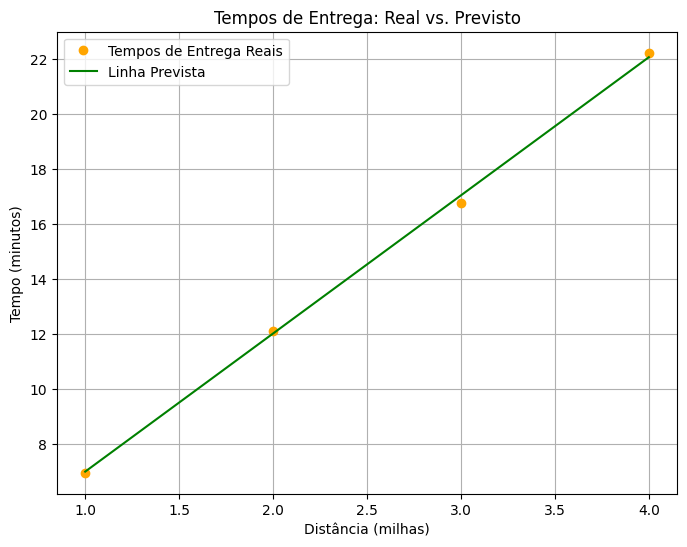

In [36]:
helper_utils.plot_results(model, distances, times)

### Faça sua Previsão

Seu modelo está treinado. Agora, o momento da verdade. **Você conseguirá fazer essa entrega de 7 milhas em menos de 30 minutos?**

Embora uma avaliação completa testaria o modelo em muitos pontos de dados não vistos, aqui você saltará diretamente para o propósito pretendido: fazer uma **previsão baseada em dados** para uma entrega específica.

* Primeiro, você definirá a variável `distance_to_predict`.
    * Ela está inicialmente configurada como `7.0` para resolver o problema original.
    * Após executar o código, você pode facilmente voltar e alterar essa única variável para obter previsões para qualquer outra distância.
* Esta variável é então usada para criar o tensor de entrada para o modelo.

In [37]:
distance_to_predict = 7.0

* Todo o processo de previsão é envolvido em um bloco `with torch.no_grad()`.
    * Isso informa ao PyTorch que você não está mais treinando, apenas fazendo uma previsão. Isso torna o processo mais rápido e eficiente.
* Um novo tensor de entrada é criado usando a variável `distance_to_predict`.
    * Ele deve ser formatado como um tensor 2D (`[[7.0]]`), pois o modelo espera essa estrutura específica, e não um número simples.
* Seu `model` treinado é chamado com este novo tensor para gerar um `predicted_time`.
* Após obter a previsão (que também é um tensor), o código extrai o valor numérico real dele usando `.item()`.

In [38]:
# Use o gerenciador de contexto torch.no_grad() para previsões eficientes
with torch.no_grad():
    # Converta a variável Python em um tensor PyTorch 2D que o modelo espera
    new_distance = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    
    # Passe os novos dados ao modelo treinado para obter uma previsão
    predicted_time = model(new_distance)
    
    # Use .item() para extrair o valor escalar do tensor para exibição
    print(f"Previsão para uma entrega de {distance_to_predict} milhas: {predicted_time.item():.1f} minutos")

    # Use o valor escalar em uma estrutura condicional para tomar a decisão final
    if predicted_time.item() > 30:
        print("\nDecisão: NÃO aceite o trabalho. Você provavelmente vai se atrasar.")
    else:
        print("\nDecisão: Aceite o trabalho. Você consegue chegar a tempo!")

Previsão para uma entrega de 7.0 milhas: 37.1 minutos

Decisão: NÃO aceite o trabalho. Você provavelmente vai se atrasar.


<br>

Você treinou e utilizou sua primeira rede neural no PyTorch para resolver um problema prático!

Seu modelo previu que uma entrega de `7 milhas` levaria mais de 30 minutos. Com base nessa previsão, você tomou a decisão baseada em dados de recusar o trabalho, protegendo-se de um possível atraso e de colocar seu emprego em risco.

## Inspecionando o Aprendizado do Modelo

Agora que você tem um modelo funcional, vamos ver a relação exata que ele aprendeu com os dados. Você pode fazer isso inspecionando os parâmetros internos do modelo: os valores finais de **peso** (*weight*) e **viés** (*bias*) que ele descobriu durante o treinamento. Esses valores definem a linha precisa que seu modelo está usando agora para fazer previsões.

In [39]:
# Acesse a primeira (e única) camada no modelo sequencial
layer = model[0]

# Obtenha os pesos (weights) e o viés (bias)
weights = layer.weight.data.numpy()
bias = layer.bias.data.numpy()

print(f"Peso: {weights}")
print(f"Viés: {bias}")

Peso: [[5.015503]]
Viés: [1.9849645]


<br>

**Interpretando os Resultados**

Estes parâmetros aprendidos têm um significado no mundo real no contexto do seu problema de entrega:

* **Peso (~5.0)**: Isso significa que, para cada milha adicional, seu modelo prevê que o tempo de entrega aumentará em cerca de 5,0 minutos.

* **Viés (~2.0)**: Isso representa o tempo base para qualquer entrega, independentemente da distância. Pense nisso como o tempo necessário para retirar o pedido e subir na bicicleta.

Seu modelo descobriu uma relação linear entre distância e tempo. Com os valores de **W** e **B** que ele aprendeu, agora ele pode prever tempos de entrega para qualquer distância usando a equação:

> <code>Time = 5.0 * Distance + 2.0</code>

## Testando Seu Modelo em Dados Mais Complexos

Sua empresa está expandindo os serviços de entrega. Para lidar com rotas mais longas de forma mais eficiente, **qualquer entrega acima de 3 milhas agora será feita de carro em vez de bicicleta.**

Isso significa que seu conjunto de dados acabou de mudar. Ele agora inclui uma mistura de entregas de bicicleta e de carro, dois tipos diferentes de viagens. Você já tem um modelo que funcionou bem antes. **Mas será que ele ainda funcionará agora?** Vamos dar uma olhada mais de perto.

* Defina o novo conjunto de dados, que inclui os dados originais de bicicleta mais novos pontos de dados para entregas de carro em distâncias mais longas.
    * `new_distances`: Um tensor contendo distâncias de 1 a 20 milhas.
    * `new_times`: Um tensor com os tempos de entrega correspondentes para o conjunto de dados combinado.

In [40]:
# Conjunto de dados combinado: bicicletas para distâncias curtas, carros para as mais longas
new_distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Tempos de entrega correspondentes em minutos
new_times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

Agora, vamos testar o quão bem o seu modelo (treinado apenas com dados de bicicletas) lida com este novo conjunto de dados misto.

* Use o seu `model` treinado para gerar previsões sobre as novas distâncias (`new_distances`).

In [41]:
# Use o modelo linear já treinado para fazer previsões
with torch.no_grad():
    predictions = model(new_distances)

* Calcule a `new_loss` entre as previsões do modelo e os tempos reais.
* Observe como o valor da perda (*loss*) impresso será *significativamente* maior do que a perda ao final do treinamento. Isso indicará um ajuste ruim (*poor fit*).

In [42]:
# Calcule a nova perda (loss)
new_loss = loss_function(predictions, new_times)
print(f"Perda nos novos dados combinados: {new_loss.item():.2f}")

Perda nos novos dados combinados: 179.26


<br>

Para entender por que a perda (*loss*) é tão alta, vamos visualizar o que está acontecendo. Este gráfico revela por que seu modelo linear tem dificuldade com os novos dados.

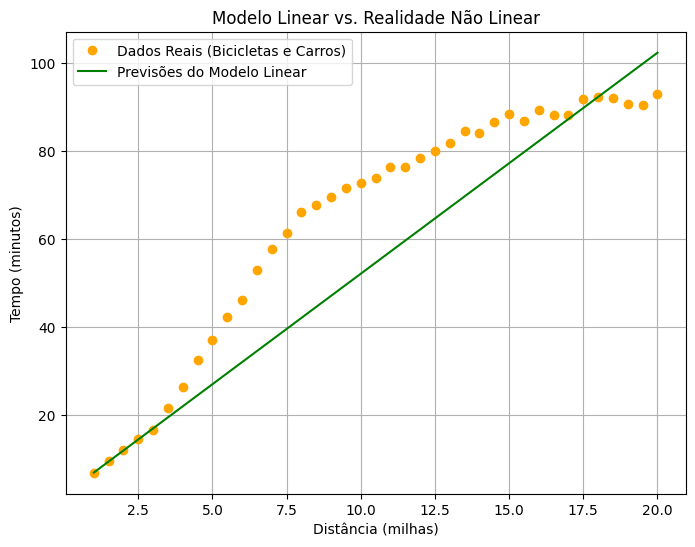

In [43]:
helper_utils.plot_nonlinear_comparison(model, new_distances, new_times)

<br>

**Por que você acha que seu modelo linear falhou?**

Seu modelo teve um bom desempenho apenas com os dados de bicicleta, onde a relação entre distância e tempo era bastante consistente. Mas, com o novo conjunto de dados, as coisas mudaram.

A perda (*loss*) é muito maior e uma rápida olhada na visualização mostrou o porquê:

* **Dados Reais (pontos laranjas)**: Os tempos de entrega seguem um padrão mais complexo. Bicicletas fazem rotas curtas e diretas. Carros lidam com o tráfego da cidade e depois aceleram em rodovias. A relação entre distância e tempo não é suave ou consistente; ela faz curvas e se desloca.
  
* **Previsões do Modelo (linha verde)**: Seu modelo só consegue desenhar uma linha reta. Ele aprendeu um único padrão: cada milha adiciona aproximadamente a mesma quantidade de tempo. Mas agora essa premissa não é mais válida.

Para capturar esses padrões não lineares, você precisa dar ao seu modelo a capacidade de aprender curvas, não apenas linhas. No próximo vídeo da aula, você descobrirá uma técnica que transforma as redes neurais, permitindo que elas deixem de ajustar apenas linhas retas para se ajustarem a padrões complexos do mundo real.

## Conclusão

Você construiu e treinou com sucesso seu primeiro modelo PyTorch para resolver o problema inicial de entrega. Você viu como um **modelo linear** pôde aprender a relação em dados simples apenas de bicicletas para tomar uma decisão correta e baseada em dados. No entanto, a verdadeira lição veio quando este modelo falhou em um conjunto de dados mais complexo contendo tanto bicicletas quanto carros. Isso revelou um conceito fundamental: um modelo linear simples, não importa o quão bem treinado, só consegue aprender padrões de linha reta e tem dificuldades quando a realidade se torna **não linear**.

Este desafio prepara perfeitamente o terreno para sua próxima aula, onde você aprenderá como dar aos seus modelos a capacidade de aprender curvas, não apenas linhas. Ao trabalhar as etapas essenciais do **Pipeline de Machine Learning** neste laboratório, você construiu uma base sólida. Entender onde e por que esse modelo simples falha é o primeiro passo crucial para a construção de redes mais avançadas, capazes de resolver problemas verdadeiramente complexos.